In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
x,y = make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [6]:
df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.151437,0.017737,-1.139430,0.525893,-2.403634,0
1,-0.653620,-2.594270,0.528715,-0.476929,-0.929421,1
2,-1.143132,1.850686,-1.053125,-1.284637,-2.429411,0
3,-1.062403,-0.204115,-1.657277,-1.484606,-3.560188,1
4,-0.334419,1.534352,-2.639500,-1.395789,-1.962071,0


In [7]:
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [14]:
import random
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [15]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [16]:

df1 = combined_sampling(df,0.5,0.5)

C:\Users\sumit\AppData\Local\Temp\ipykernel_8648\4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [17]:

df2 = combined_sampling(df,0.5,0.5)

C:\Users\sumit\AppData\Local\Temp\ipykernel_8648\4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [18]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\sumit\AppData\Local\Temp\ipykernel_8648\4042980177.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [19]:

print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col3', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')
Index(['col5', 'col3', 'target'], dtype='object')


In [20]:
df3

,col5,col3,target
66,0.372496,-1.943118,0
83,-2.359039,-1.584502,0
23,1.532395,-1.678916,1
61,0.239307,-0.244846,1
10,-0.469069,-2.063205,0
16,0.072134,-0.321218,0
7,-0.674760,-0.108595,1
2,-2.429411,-1.053125,0
49,-0.019706,-2.213725,0
9,-0.794497,-2.223297,0


In [21]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [22]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [23]:
from sklearn.tree import plot_tree

[Text(0.4090909090909091, 0.9444444444444444, 'x[0] <= -0.775\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.3181818181818182, 0.8333333333333334, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.36363636363636365, 0.8888888888888888, 'True  '),
 Text(0.5, 0.8333333333333334, 'x[1] <= -1.165\ngini = 0.432\nsamples = 38\nvalue = [26, 12]'),
 Text(0.4545454545454546, 0.8888888888888888, '  False'),
 Text(0.4090909090909091, 0.7222222222222222, 'x[0] <= -0.288\ngini = 0.5\nsamples = 24\nvalue = [12, 12]'),
 Text(0.18181818181818182, 0.6111111111111112, 'x[1] <= -2.111\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.2727272727272727, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6363636363636364, 0.6111111111111112, 'x[0] <= 1.343\ngini = 0.469\nsamples = 16\nvalue = [6, 10]'),
 Text(0.45454545454545453, 0.5, 'x[0] <= 0.88\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.3636363

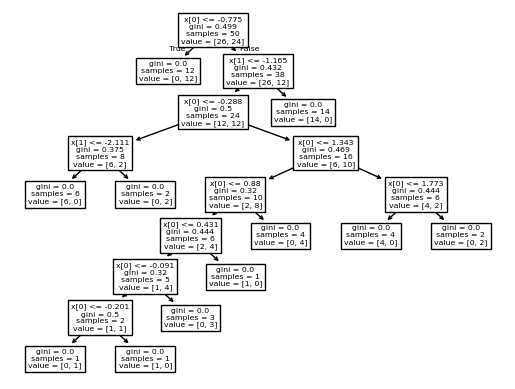

In [24]:
plot_tree(clf1)

[Text(0.40625, 0.9444444444444444, 'x[0] <= 0.655\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.125, 0.8333333333333334, 'x[1] <= -2.186\ngini = 0.388\nsamples = 19\nvalue = [5, 14]'),
 Text(0.265625, 0.8888888888888888, 'True  '),
 Text(0.0625, 0.7222222222222222, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.1875, 0.7222222222222222, 'x[0] <= -1.564\ngini = 0.291\nsamples = 17\nvalue = [3, 14]'),
 Text(0.125, 0.6111111111111112, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.6111111111111112, 'x[0] <= -0.406\ngini = 0.219\nsamples = 16\nvalue = [2, 14]'),
 Text(0.1875, 0.5, 'x[0] <= -0.888\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.125, 0.3888888888888889, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.25, 0.3888888888888889, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3125, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.6875, 0.8333333333333334, 'x[1] <= -0.048\ngini = 0.437\nsamples = 31\nvalue = [21, 10]'),
 Text(0.5468

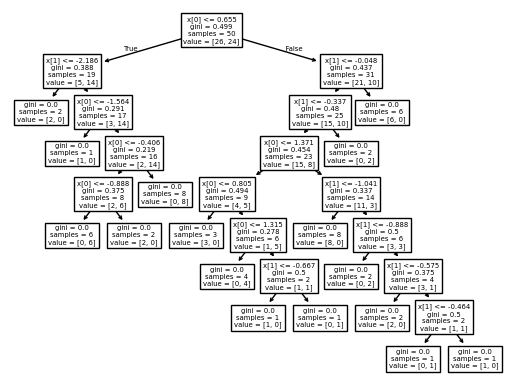

In [25]:


plot_tree(clf2)

[Text(0.3333333333333333, 0.9166666666666666, 'x[0] <= -2.764\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.2222222222222222, 0.75, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.2777777777777778, 0.8333333333333333, 'True  '),
 Text(0.4444444444444444, 0.75, 'x[1] <= -0.283\ngini = 0.467\nsamples = 43\nvalue = [27, 16]'),
 Text(0.38888888888888884, 0.8333333333333333, '  False'),
 Text(0.2222222222222222, 0.5833333333333334, 'x[1] <= -1.811\ngini = 0.35\nsamples = 31\nvalue = [24, 7]'),
 Text(0.1111111111111111, 0.4166666666666667, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.3333333333333333, 0.4166666666666667, 'x[1] <= -0.776\ngini = 0.455\nsamples = 20\nvalue = [13, 7]'),
 Text(0.2222222222222222, 0.25, 'x[0] <= -2.205\ngini = 0.486\nsamples = 12\nvalue = [5, 7]'),
 Text(0.1111111111111111, 0.08333333333333333, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.4444

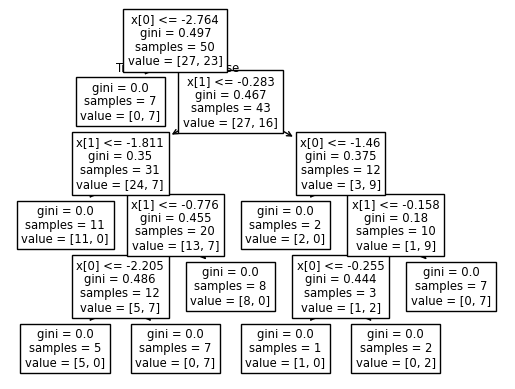

In [26]:
plot_tree(clf3)

In [28]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [29]:

clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [30]:

clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\sumit\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [31]:

df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
95,0.343785,2.165547,-0.718772,-2.639355,0.134649,0
82,1.378223,1.450679,0.693056,-1.414310,0.037763,0
64,0.082104,-0.991300,-0.996874,-0.683830,-3.099426,1
58,-1.139976,0.116334,-1.203434,-0.959894,-3.369369,1
48,0.635919,-1.045717,-0.950989,-1.098942,-1.447626,1
66,0.064861,2.395181,-1.943118,-3.315329,0.372496,0
25,1.360122,1.751801,0.698438,-0.765898,-0.861254,0
59,0.590329,2.499869,-0.734147,-3.483608,1.096770,0
82,1.378223,1.450679,0.693056,-1.414310,0.037763,0
15,3.505360,-3.102360,0.375522,0.419703,0.510801,1
